In [1]:
import networkx as nx
import pandas as pd
from IPython.display import display
from community import community_louvain
import matplotlib.pyplot as plt
from itertools import combinations
from collections import defaultdict
from concurrent.futures import ThreadPoolExecutor, as_completed

In [2]:
DATA_PATH_CH9 = "fraud_transactions.csv" # Path to the transaction data

try:
    transactions_df = pd.read_csv(DATA_PATH_CH9)
    print(f"'{DATA_PATH_CH9}' loaded successfully.")
    print("--------------------------------------------------")
    print("First 5 rows of the transaction dataset:")
    display(transactions_df.head())
    print("\n--------------------------------------------------")
    print(f"Dataset Shape: {transactions_df.shape}")
    print("--------------------------------------------------")
    print("Dataset Info:")
    transactions_df.info()
    print("\n--------------------------------------------------")
    if 'is_fraud' in transactions_df.columns:
        print("Distribution of 'is_fraud' label:")
        display(transactions_df['is_fraud'].value_counts(normalize=True).reset_index().rename(
            columns={'index': 'Is_Fraud', 'is_fraud': 'Proportion'}
        ))
    else:
        print("Note: 'is_fraud' column not found.")
    print("--------------------------------------------------")
except FileNotFoundError:
    print(f"Error: '{DATA_PATH_CH9}' not found. Please ensure the file is available.")
    transactions_df = None

'fraud_transactions.csv' loaded successfully.
--------------------------------------------------
First 5 rows of the transaction dataset:


,transaction_id,user_id,transaction_time,ip,device_id,phone_number,credit_card_number,order_item,amount,is_fraud
0,05987d33-9bcd-4455-9d7c-2f043b007b10,0,2024-05-07,219.20.206.172,8efe3214-ea7f-47ef-bb30-716e28f02600,(527)638-2221x33874,4908554227138584,Accessories,201631,False
1,013414be-3e37-48fb-aab2-5f42a4933db8,0,2024-05-09,219.20.206.172,8efe3214-ea7f-47ef-bb30-716e28f02600,(527)638-2221x33874,4908554227138584,Kids Products,281063,False
2,c6d1eed6-2c40-44f0-8a6f-fec0f8f7a83b,0,2024-05-12,219.20.206.172,8efe3214-ea7f-47ef-bb30-716e28f02600,(527)638-2221x33874,4908554227138584,Cosmetics,279119,False
3,90321501-3b4f-4cd3-92e9-ae1531b6b705,0,2024-05-01,219.20.206.172,8efe3214-ea7f-47ef-bb30-716e28f02600,(527)638-2221x33874,4908554227138584,Accessories,253019,False
4,2169fe4b-772a-45ef-9478-dbc48ee0e331,0,2024-05-09,219.20.206.172,8efe3214-ea7f-47ef-bb30-716e28f02600,(527)638-2221x33874,4908554227138584,Food,170733,False



--------------------------------------------------
Dataset Shape: (14813, 10)
--------------------------------------------------
Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14813 entries, 0 to 14812
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   transaction_id      14813 non-null  object
 1   user_id             14813 non-null  int64 
 2   transaction_time    14813 non-null  object
 3   ip                  14813 non-null  object
 4   device_id           14813 non-null  object
 5   phone_number        14813 non-null  object
 6   credit_card_number  14813 non-null  int64 
 7   order_item          14813 non-null  object
 8   amount              14813 non-null  int64 
 9   is_fraud            14813 non-null  bool  
dtypes: bool(1), int64(3), object(6)
memory usage: 1.0+ MB

--------------------------------------------------
Distribution of 'is_fraud' label:


,Proportion,proportion
0,False,0.982245
1,True,0.017755


--------------------------------------------------


In [3]:
if transactions_df is not None:
    G = nx.Graph()

    node_types_and_columns = {
        'user': 'user_id', 'ip': 'ip', 'device': 'device_id',
        'phone': 'phone_number', 'card': 'credit_card_number'
    }

    print("Preparing nodes for the graph...")
    for node_type, col_name in node_types_and_columns.items():
        for entity_id in transactions_df[col_name].unique():
            G.add_node(f"{node_type}_{entity_id}", type=node_type)
    print(f"Initial nodes added. Total nodes: {G.number_of_nodes()}")

    edges_to_add_with_attributes = defaultdict(lambda: {'weight': 0, 'transactions': []})

    def process_transaction_row(index_row_tuple):
        index, row = index_row_tuple
        transaction_entities_in_row = []
        for node_type_key, col_name_val in node_types_and_columns.items():
            transaction_entities_in_row.append(f"{node_type_key}_{row[col_name_val]}")
        row_edges = []
        for node1, node2 in combinations(sorted(transaction_entities_in_row), 2):
            row_edges.append(((node1, node2), row['transaction_id']))
        return row_edges

    print("\nProcessing transactions in parallel to prepare edge data...")

    prepared_edges_nested_list = []
    with ThreadPoolExecutor(max_workers=8) as executor: # Using 8 worker threads
        futures = [executor.submit(process_transaction_row, item) for item in transactions_df.iterrows()]
        count = 0
        for future in as_completed(futures):
            prepared_edges_nested_list.extend(future.result())
            count += 1
            if count % 1000 == 0 and count > 0: # Print progress every 1000 transactions
                print(f"Processed {count} transactions for edge preparation...")

    print(f"All {len(transactions_df)} transactions processed for edge preparation.")

    print("\nAggregating edge data and adding edges to the graph...")
    for (node1, node2), transaction_id in prepared_edges_nested_list:
        edges_to_add_with_attributes[(node1, node2)]['weight'] += 1
        edges_to_add_with_attributes[(node1, node2)]['transactions'].append(transaction_id)

    for (node1, node2), attributes in edges_to_add_with_attributes.items():
        G.add_edge(node1, node2, weight=attributes['weight'], transactions=attributes['transactions'])

    print("\nGraph construction completed.")
    print(f"Number of nodes in the graph: {G.number_of_nodes()}")
    print(f"Number of edges in the graph: {G.number_of_edges()}")
else:
    print("transactions_df not loaded. Skipping graph construction.")
    G = None

Preparing nodes for the graph...
Initial nodes added. Total nodes: 14906

Processing transactions in parallel to prepare edge data...


Processed 1000 transactions for edge preparation...
Processed 2000 transactions for edge preparation...
Processed 3000 transactions for edge preparation...
Processed 4000 transactions for edge preparation...
Processed 5000 transactions for edge preparation...
Processed 6000 transactions for edge preparation...
Processed 7000 transactions for edge preparation...
Processed 8000 transactions for edge preparation...
Processed 9000 transactions for edge preparation...
Processed 10000 transactions for edge preparation...
Processed 11000 transactions for edge preparation...
Processed 12000 transactions for edge preparation...
Processed 13000 transactions for edge preparation...
Processed 14000 transactions for edge preparation...
All 14813 transactions processed for edge preparation.

Aggregating edge data and adding edges to the graph...

Graph construction completed.
Number of nodes in the graph: 14906
Number of edges in the graph: 30567


In [4]:
# Ensure NetworkX (nx) is imported and G is the constructed graph from Listing 9.2
# Ensure pandas as pd and display from IPython.display are imported

if G is not None and G.number_of_nodes() > 0: 
    print("\nPerforming Louvain community detection...")
    try:
        import community.community_louvain as community_louvain 
        partition = community_louvain.best_partition(G, random_state=42, resolution=1.0) 
        nx.set_node_attributes(G, partition, 'community_id')
        num_communities = len(set(partition.values()))
        print(f"Louvain algorithm detected {num_communities} communities.")
        
    except ImportError:
        print("Error: 'community_louvain' library not found. Please install it using 'pip install python-louvain'.")
        partition = None
    except Exception as e:
        print(f"An error occurred during community detection: {e}")
        partition = None
else:
    print("Graph G not available or empty. Skipping community detection.")
    partition = None # Ensure partition is defined


Performing Louvain community detection...


Louvain algorithm detected 2913 communities.


In [5]:
if G is not None and partition is not None:
    # Group nodes by their community ID
    communities_dict_nodes = defaultdict(list)
    for node, comm_id in partition.items():
        communities_dict_nodes[comm_id].append(node)

    all_community_node_lists_sorted = [
        nodes for comm_id, nodes in sorted(communities_dict_nodes.items())
    ]

    print(f"Prepared {len(all_community_node_lists_sorted)} communities for detailed analysis.")

    # Define a function to analyze the characteristics of a single community
    def analyze_community_details_func(nodes_in_comm):
        """
        Calculates density, size, and node type counts for a given list of nodes
        representing a community within the graph G.
        """
        if not nodes_in_comm:
            # Return default values for an empty community node list
            return [0.0, 0, {}]

        # Create a subgraph containing only the nodes of the current community
        subgraph_comm = G.subgraph(nodes_in_comm)

        # Calculate the density of the subgraph
        # Density is the ratio of actual edges to all possible edges in the subgraph.
        density_comm = nx.density(subgraph_comm)

        # Get the size of the community (number of nodes)
        size_comm = len(nodes_in_comm)

        # Count the occurrences of each node type within this community
        type_counts_comm = defaultdict(int)
        for node_item in nodes_in_comm:
            # G.nodes[node_item] gives attributes of the node, including 'type'
            type_counts_comm[G.nodes[node_item].get('type', 'Unknown')] += 1

        return [density_comm, size_comm, dict(type_counts_comm)] # Return calculated metrics

    print("Function 'analyze_community_details_func' defined for community analysis.")

else:
    print("Graph G or partition not available. Skipping community analysis preparation.")
    all_community_node_lists_sorted = [] # Define for subsequent cells not to fail

Prepared 2913 communities for detailed analysis.
Function 'analyze_community_details_func' defined for community analysis.


In [6]:
community_analysis_data = [] # To store results from all communities

if 'all_community_node_lists_sorted' in locals() and all_community_node_lists_sorted:
    print(f"\nAnalyzing {len(all_community_node_lists_sorted)} communities in parallel (max_workers=8)...")

    with ThreadPoolExecutor(max_workers=8) as executor:
        future_to_original_index = {
            executor.submit(analyze_community_details_func, nodes_list): i
            for i, nodes_list in enumerate(all_community_node_lists_sorted)
        }

        processed_count = 0
        sorted_community_ids = list(sorted(communities_dict_nodes.keys()))

        for future_item in as_completed(future_to_original_index):
            original_list_index = future_to_original_index[future_item]
            try:
                density_val, size_val, type_counts_dict = future_item.result()

                actual_community_id_for_row = list(sorted(communities_dict_nodes.keys()))[original_list_index]

                analysis_row_dict = {'Community ID': actual_community_id_for_row,
                                     'Size': size_val,
                                     'Density': density_val}
                analysis_row_dict.update(type_counts_dict)
                community_analysis_data.append(analysis_row_dict)
                processed_count +=1
                if processed_count % 500 == 0: # Progress update
                    print(f"Analyzed {processed_count} communities...")

            except Exception as ex:
                print(f"Error analyzing community (original list index {original_list_index}): {ex}")

    if community_analysis_data:
        community_details_df = pd.DataFrame(community_analysis_data)
        # Ensure all node type columns exist, filling with 0 if a type is not in a community
        for node_type_key in node_types_and_columns.keys():
            if node_type_key not in community_details_df.columns:
                community_details_df[node_type_key] = 0
            community_details_df[node_type_key] = community_details_df[node_type_key].fillna(0).astype(int)

        community_details_df_sorted = community_details_df.sort_values(by='Size', ascending=False)

        print("\nTop 5 largest communities with their characteristics:")
        # Define the desired order of columns for display
        display_cols_ordered = ['Community ID', 'Size', 'Density'] + list(node_types_and_columns.keys())
        # Filter for columns that actually exist in the DataFrame to prevent errors
        existing_display_cols_ordered = [col for col in display_cols_ordered if col in community_details_df_sorted.columns]
        display(community_details_df_sorted.head()[existing_display_cols_ordered])
    else:
        print("No community analysis results to display.")
else:
    print("Node lists for communities not available. Skipping detailed community analysis.")
    community_details_df_sorted = pd.DataFrame() # Define for subsequent cells not to fail


Analyzing 2913 communities in parallel (max_workers=8)...
Analyzed 500 communities...
Analyzed 1000 communities...
Analyzed 1500 communities...
Analyzed 2000 communities...
Analyzed 2500 communities...

Top 5 largest communities with their characteristics:


,Community ID,Size,Density,user,ip,device,phone,card
161,161,128,0.057087,30,30,30,30,8
55,55,125,0.057806,30,5,30,30,30
37,37,103,0.105654,30,30,6,7,30
1946,1948,5,1.000000,1,1,1,1,1
1938,1940,5,1.000000,1,1,1,1,1



Visualizing the largest community (ID: 161.0)...
Number of nodes in this community subgraph: 128
Number of edges in this community subgraph: 464


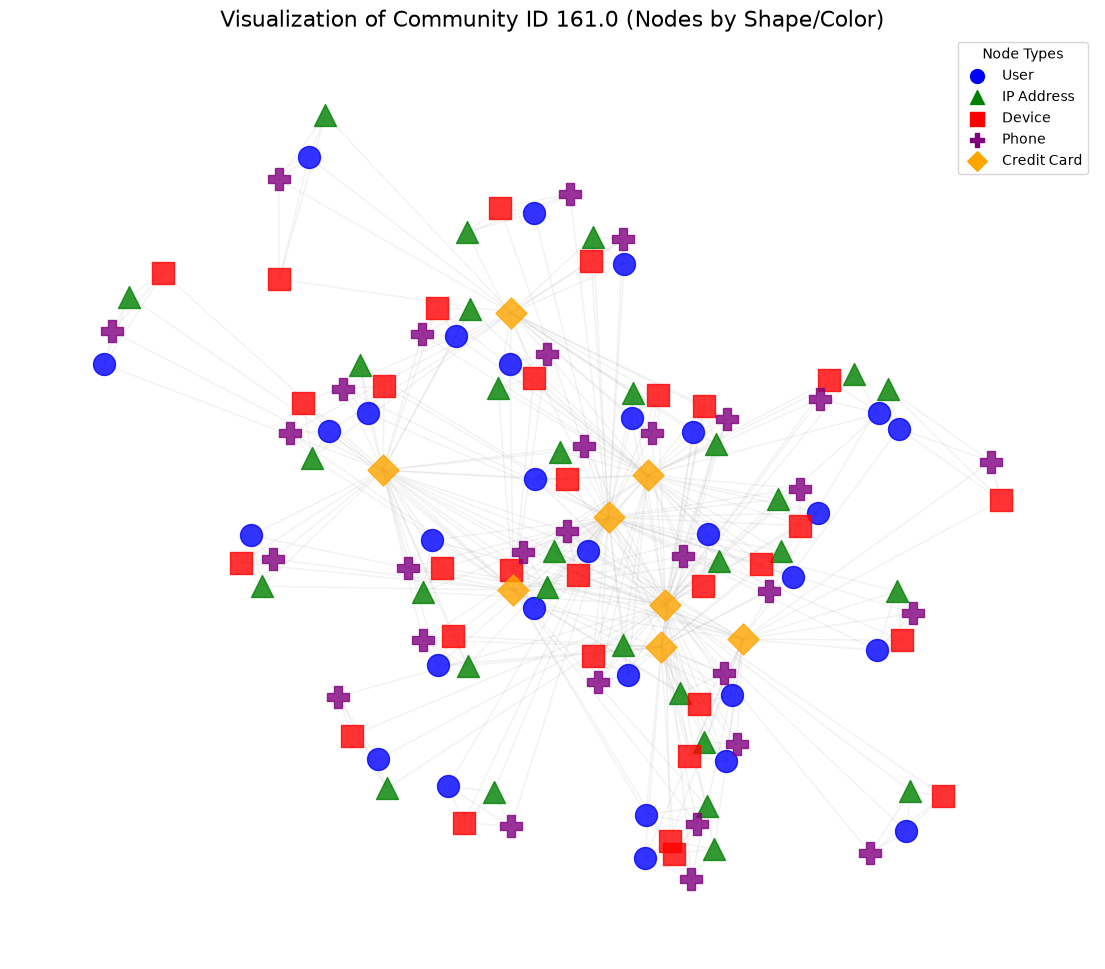

In [7]:
if 'G' in locals() and G is not None and \
   'partition' in locals() and partition is not None and \
   'community_details_df_sorted' in locals() and not community_details_df_sorted.empty:

    target_community_id_to_viz = community_details_df_sorted.iloc[0]['Community ID']
    print(f"\nVisualizing the largest community (ID: {target_community_id_to_viz})...")

    nodes_in_selected_community = [
        node for node, comm_id in partition.items() if comm_id == target_community_id_to_viz
    ]

    if nodes_in_selected_community:
        community_subgraph_to_viz = G.subgraph(nodes_in_selected_community)

        print(f"Number of nodes in this community subgraph: {community_subgraph_to_viz.number_of_nodes()}")
        print(f"Number of edges in this community subgraph: {community_subgraph_to_viz.number_of_edges()}")

        plt.figure(figsize=(14, 12)) # Adjust figure size for better visualization

        node_visualization_attrs = {
            'user': {'marker': 'o', 'color': 'blue', 'label': 'User'},
            'ip': {'marker': '^', 'color': 'green', 'label': 'IP Address'},
            'device': {'marker': 's', 'color': 'red', 'label': 'Device'},
            'phone': {'marker': 'P', 'color': 'purple', 'label': 'Phone'}, # 'P' is a plus (filled)
            'card': {'marker': 'D', 'color': 'orange', 'label': 'Credit Card'}
        }
        default_marker_viz = 'x' # Fallback marker
        default_color_viz = 'grey'

        pos_community_viz = nx.spring_layout(community_subgraph_to_viz, k=0.3, iterations=50, seed=42)

        # Draw nodes for each type with its specific marker and color
        for node_type_key, attrs in node_visualization_attrs.items():
            nodelist_to_draw = [node for node in community_subgraph_to_viz.nodes()
                                if community_subgraph_to_viz.nodes[node].get('type') == node_type_key]
            if nodelist_to_draw: # Only draw if nodes of this type exist in the subgraph
                nx.draw_networkx_nodes(community_subgraph_to_viz, pos_community_viz,
                                       nodelist=nodelist_to_draw,
                                       node_shape=attrs['marker'],
                                       node_color=attrs['color'], # Color can still be used for screen
                                       node_size=250, # Adjust size
                                       label=attrs['label'],
                                       alpha=0.8)

        # Draw edges with some transparency
        nx.draw_networkx_edges(community_subgraph_to_viz, pos_community_viz, alpha=0.15, edge_color='darkgrey')

        # Create a legend based on the markers and labels defined
        legend_handles = [plt.scatter([],[], marker=attrs['marker'], color=attrs['color'], label=attrs['label'], s=100)
                          for attrs in node_visualization_attrs.values()]
        plt.legend(handles=legend_handles, title="Node Types", loc='best', markerscale=1.0, fontsize=10)

        plt.title(f"Visualization of Community ID {target_community_id_to_viz} (Nodes by Shape/Color)", fontsize=16)
        plt.axis('off') # Turn off the axis for a cleaner graph visualization
        plt.show()
    else:
        print(f"No nodes found for community ID {target_community_id_to_viz} to visualize.")
else:
    print("Graph, partition, or community details DataFrame not available. Skipping community visualization.")